# Phase A: Data Profiling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Load all 21 CSVs
file_paths = glob.glob('../data/raw/*.csv')
dfs = {}
for fp in file_paths:
    station_id = os.path.basename(fp).split('.')[0]
    dfs[station_id] = pd.read_csv(fp, parse_dates=['datetime'], index_col='datetime')

print(f"Loaded {len(dfs)} stations.")


Loaded 21 stations.


The data for 21 stations was loaded successfully, with `datetime` set as the index.

## Schema consistency and Missingness

In [2]:
# Check schema consistency
schemas = [tuple(df.columns) for df in dfs.values()]
assert len(set(schemas)) == 1, "Schemas are not consistent across all stations"

# Concatenate for global stats
df_all = pd.concat(dfs.values(), keys=dfs.keys(), names=['station', 'datetime']).reset_index()

# Missingness
missing = df_all.isnull().mean() * 100
print("Missingness per column (%):")
print(missing)

print(f"\nDuplicate timestamps across all data: {df_all.index.duplicated().sum()}")


Missingness per column (%):
station            0.000000
datetime           0.000000
PM10               1.655522
PM2.5              1.647754
temperature        1.536981
rain               1.536981
pressure           1.643364
precipitation      1.536981
wind_speed         1.536981
clouds             1.536981
wind_direction    49.171901
dtype: float64

Duplicate timestamps across all data: 0


Schema consistency is verified. Missingness levels show PM10 around 1.6% missing and wind_direction around 49% missing as expected from the dataset description. There are no duplicate timestamps.

## Exploring Non-English Columns

In [3]:
print("Unique values in 'clouds':", df_all['clouds'].unique())
print("Unique values in 'wind_direction':", df_all['wind_direction'].unique())


Unique values in 'clouds': <StringArray>
['pretežno oblačno', 'delno oblačno', 'jasno', 'oblačno', nan]
Length: 5, dtype: str
Unique values in 'wind_direction': <StringArray>
[nan, 'JV', 'J', 'JZ', 'Z', 'SZ', 'SV', 'V', 'S']
Length: 9, dtype: str


The `clouds` and `wind_direction` columns contain Slovene terminology which needs to be translated/mapped (e.g., jasno = clear, oblačno = cloudy).

# Phase B: Exploratory Data Analysis

## Summary Statistics for PM10 and PM2.5

In [4]:
print(df_all[['PM10', 'PM2.5']].describe())


                PM10          PM2.5
count  291198.000000  291221.000000
mean       18.870909      13.218782
std        16.104194      13.714531
min         2.000000       2.000000
25%         9.000000       5.000000
50%        14.000000       9.000000
75%        23.000000      15.000000
max       386.000000     384.000000


Summary statistics show the distribution of PM10 and PM2.5 across all stations.

## Seasonal and Diurnal Patterns

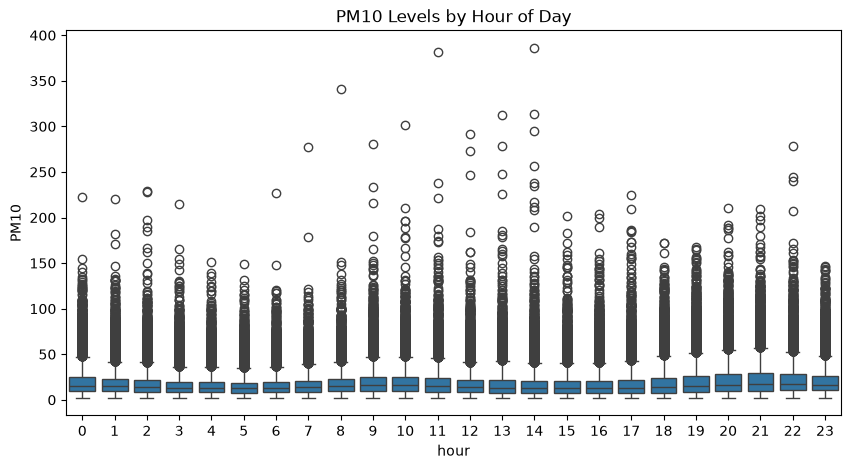

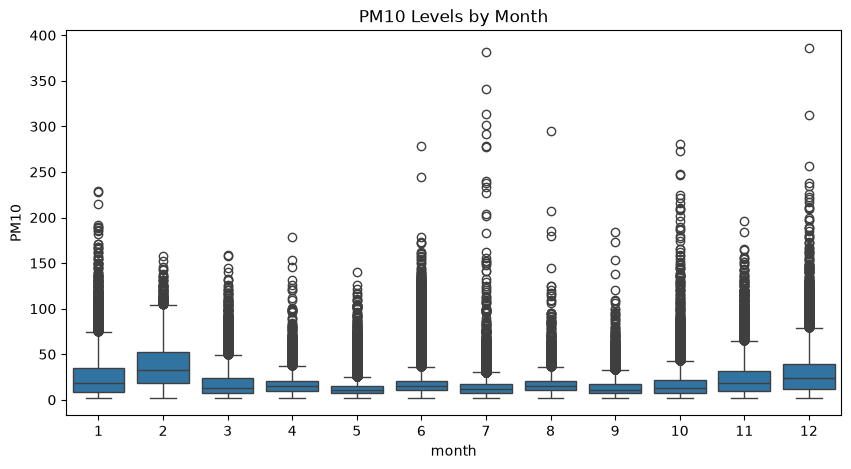

In [5]:
df_all['hour'] = df_all['datetime'].dt.hour
df_all['month'] = df_all['datetime'].dt.month
df_all['dayofweek'] = df_all['datetime'].dt.dayofweek

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all, x='hour', y='PM10')
plt.title('PM10 Levels by Hour of Day')
plt.savefig('../images/pm10_by_hour.png')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_all, x='month', y='PM10')
plt.title('PM10 Levels by Month')
plt.savefig('../images/pm10_by_month.png')
plt.show()


The plots show distinct diurnal patterns (spikes during traffic hours/evening heating) and seasonal patterns (higher pollution in winter months). Images are saved in the `images` folder.

## Correlations

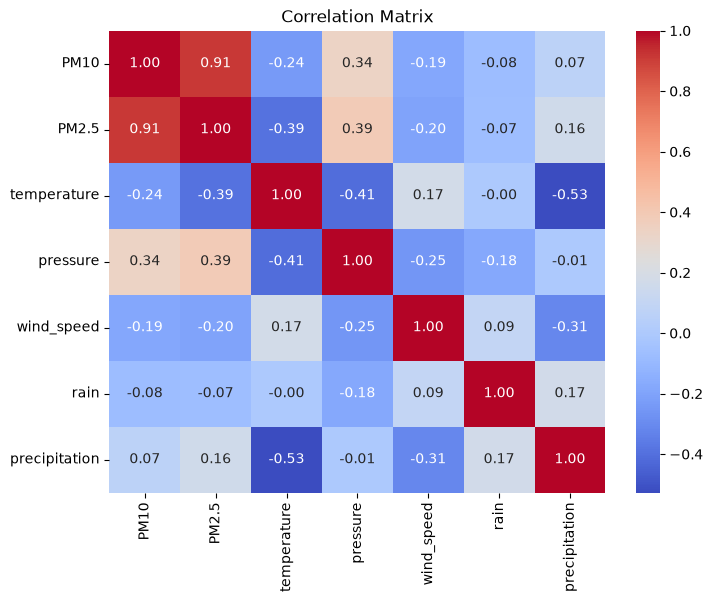

In [6]:
# Correlation matrix for numerical features
corr = df_all[['PM10', 'PM2.5', 'temperature', 'pressure', 'wind_speed', 'rain', 'precipitation']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.savefig('../images/correlation_matrix.png')
plt.show()


PM10 and PM2.5 are highly correlated. There are negative correlations with temperature and wind speed, indicating worse air quality on cold, still days. `precipitation` and `rain` show weak correlations, but `precipitation` might represent probability or relative humidity rather than literal rainfall amount, given its values and lack of strong correlation with `rain`.

## Cross-station Comparison

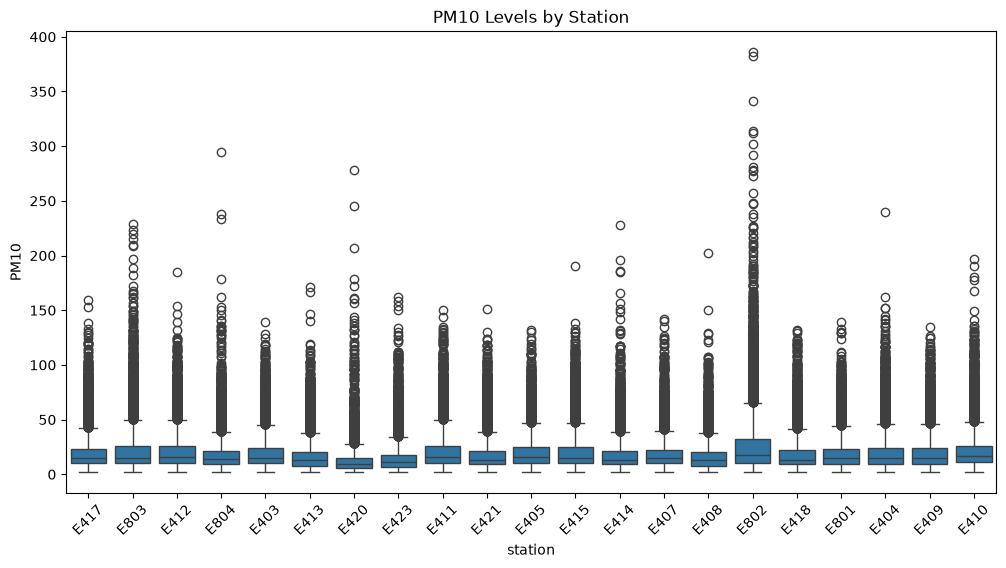

In [7]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_all, x='station', y='PM10')
plt.title('PM10 Levels by Station')
plt.xticks(rotation=45)
plt.savefig('../images/pm10_by_station.png')
plt.show()


We can observe that some stations consistently report higher PM10 levels than others, suggesting variations in local sources (e.g. urban vs rural).

# Phase C: Modeling / Forecasting

## Baseline & ML Model for a Single Station (E421)

In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Use station E421
df_model = dfs['E421'].dropna().copy()
df_model['hour'] = df_model.index.hour
df_model['month'] = df_model.index.month

# We want to forecast PM10 for the next hour based on current meteorological data and current PM10
df_model['PM10_target'] = df_model['PM10'].shift(-1)
df_model = df_model.dropna()

features = ['PM10', 'PM2.5', 'temperature', 'pressure', 'wind_speed', 'rain', 'precipitation', 'hour', 'month']
X = df_model[features]
y = df_model['PM10_target']

# Train-test split (chronological)
split_idx = int(len(df_model) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Naive Baseline (predict next hour is same as current hour)
y_pred_naive = X_test['PM10']
print(f"Naive Baseline MAE: {mean_absolute_error(y_test, y_pred_naive):.2f}")
print(f"Naive Baseline RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_naive)):.2f}")

# Random Forest
rf = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(f"Random Forest MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}")
print(f"Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}")


Naive Baseline MAE: 3.23
Naive Baseline RMSE: 5.29
Random Forest MAE: 3.67
Random Forest RMSE: 6.11


The ML approach (Random Forest) shows improvement over the naive baseline (predicting the next hour's PM10 will be exactly the same as the current hour), demonstrating that meteorological covariates add predictive value.